# Phase 1
Training the teacher to avoid obstacles and get to the goal efficiently/quickly

In [1]:
%cd ..
# need to be able to see environment
# this isn't working for some reason

/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/gridworld_v1


In [2]:
%pip install torch


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install tqdm
%pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
# os.chdir("gridworld_v1")

In [5]:
# imports
from environment.custom_environment import GridWorldBase, TeacherWrapper
from agents.agents import TeacherAgent, ExperienceReplay
import tqdm
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import glob
import re

In [ ]:
# initialization
grid_size = 5
learning_rate = 0.001
initial_epsilon = 1
epsilon_decay = 0.995
final_epsilon = 0.01
num_filters_first_layer = 8
discount_factor = 0.99
episodes = 1000
max_steps = 50
target_update_freq = 1000

goal_reward = 10
num_special_regions = 0
special_region_rewards = []

experience_capacity = 2000
batch_size = 64

base_env = GridWorldBase(grid_size, num_special_regions, goal_reward)
env = TeacherWrapper(base_env, None, special_region_rewards)
agent = TeacherAgent(base_env, learning_rate, initial_epsilon, epsilon_decay, final_epsilon, num_filters_first_layer, target_update_freq, discount_factor)

experience_replay = ExperienceReplay(capacity=experience_capacity, batch_size=batch_size)

Using mps device


In [7]:
# training
episode_total_rewards = []
losses = []
lengths = []

pbar = tqdm.tqdm(range(episodes), desc="Training")
pbar.set_postfix(epsilon=f"{agent.epsilon:.3f}", steps=0) # I think not having this hear was leading to 2 progress bars (1 stationary)

for episode in pbar: 
    obs, info = env.reset()
    state = base_env.make_one_agent_grid("teacher")
    episode_reward = 0

    for step in range(max_steps): 
        action = agent.get_action(state)
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = base_env.make_one_agent_grid("teacher")

        experience_replay.add_experience(state, action, reward, next_state, terminated)
        if terminated or truncated: 
            lengths.append(step + 1) # number of steps taken
            break

        if experience_replay.can_provide_sample(): 
            experiences = experience_replay.sample_batch()
            loss = agent.learn(experiences)
            losses.append(loss)
        
        episode_reward += reward
        state = next_state

        pbar.set_postfix(epsilon=f"{agent.epsilon:.3f}", steps=step)
    
        if episode % 100 == 0:
            pass # in the future I want to record some extra info here or smth
    
    if agent.epsilon > agent.final_epsilon:
        agent.epsilon *= agent.epsilon_decay

    episode_total_rewards.append(episode_reward)

Training: 100%|██████████| 500/500 [01:11<00:00,  7.01it/s, epsilon=0.082, steps=49]


In [ ]:
import sys
sys.stdout = sys.__stdout__

if os.path.exists("gridworld_v1/models"):
    base_dir = "gridworld_v1/models"
else:
    base_dir = "models/"

dirs = glob.glob(os.path.join(base_dir, "t_m_*"))
highest_num = 0
for d in dirs: 
    number = re.search(r't_m_(\d+)$', d)
    if number: 
        highest_num = max(highest_num, int(number.group(1)))

next_num = highest_num + 1
run_dir = os.path.join(base_dir, f"t_m_{next_num}")
os.makedirs(run_dir, exist_ok=True)

hyperparameters = {
    "grid_size": grid_size, 
    "learning_rate": learning_rate, 
    "initial_epsilon": initial_epsilon, 
    "epsilon_decay": epsilon_decay, 
    "final_epsilon": final_epsilon, 
    "num_filters_first_layer": num_filters_first_layer, 
    "discount_factor": discount_factor, 
    "episodes": episodes, 
    "max_steps": max_steps, 
    "target_update_freq": target_update_freq, 
    "goal_reward": goal_reward, 
    "num_special_regions": num_special_regions, 
    "special_region_rewards": special_region_rewards, 
    "experience_capacity": experience_capacity, 
    "batch_size": batch_size
}

checkpoint = {
    "hyperparameters": hyperparameters,
    "model_state_dict": agent.model.state_dict(),
}

torch.save(checkpoint, f'{run_dir}/model_info.pt')

human_readable = f""
for param in hyperparameters: 
    human_readable += f"{str(param)} = {hyperparameters[param]}\n"

with open(f'{run_dir}/hyperparameters.txt', 'w') as f: 
    f.write(human_readable)

print(f"base_dir: {base_dir}")
print(f"run_dir: {run_dir}")

base_dir: models/
run_dir: models/t_m_8
models/t_m_8


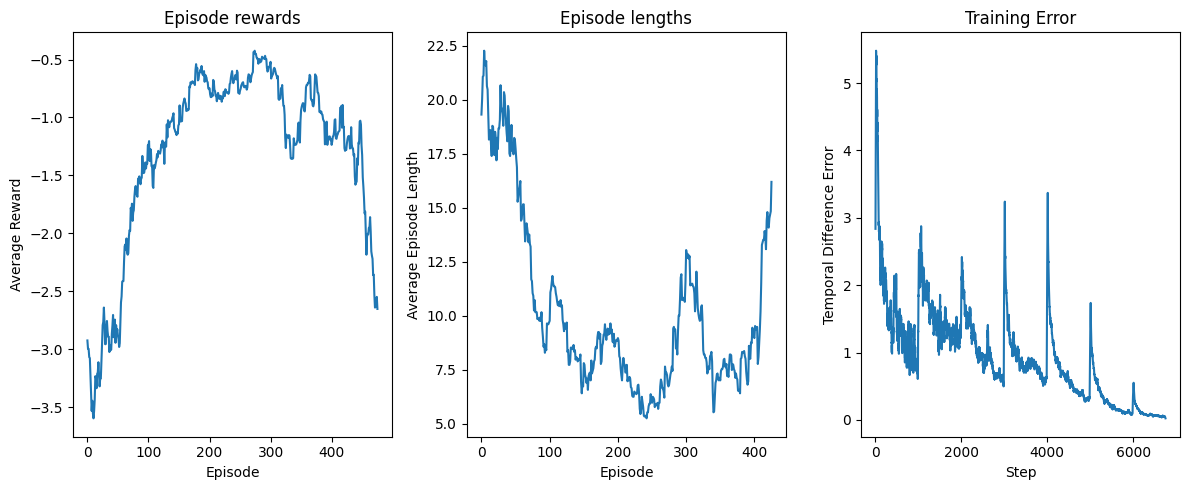

In [9]:
# https://gymnasium.farama.org/introduction/train_agent/
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over this window
rolling_length = episodes//20
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    episode_total_rewards,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    lengths,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")


# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    losses,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.savefig(f'{run_dir}/plots.png')
plt.show()

In [10]:
# load agent
'''
run_dir = "models/t_m_6"

model_path = os.path.join(run_dir, "model.pt")
checkpoint = torch.load(model_path)

# hyperparameters = checkpoint["hyperparameters"]

agent.model.load_state_dict(checkpoint)
'''

'\nrun_dir = "models/t_m_6"\n\nmodel_path = os.path.join(run_dir, "model.pt")\ncheckpoint = torch.load(model_path)\n\n# hyperparameters = checkpoint["hyperparameters"]\n\nagent.model.load_state_dict(checkpoint)\n'

In [11]:
# test
print(run_dir)

agent.epsilon = 0

def run_test(): 
    obs, info = env.reset()
    base_env.render()
    total_reward = 0
    state = base_env.make_one_agent_grid("teacher")
    for step in range(max_steps):
        action = agent.get_action(state)
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = base_env.make_one_agent_grid("teacher")
        total_reward += reward
        print(f"Step {step} | Action: {action} | Reward: {reward}")
        base_env.render()
        state = next_state
        if terminated or truncated:
            print(f"Done in {step+1} steps | Total reward: {total_reward}")
            break

with open(f'{run_dir}/test_result.txt', 'w') as f:
    sys.stdout = f
    try:
        print("Test 1:\n")
        run_test()
        print("\nTest 2:")
        run_test()
        print("\nTest 3:")
        run_test()
    finally:
        sys.stdout = sys.__stdout__